In [122]:
import pandas as pd

online_retail = pd.read_excel('./data/Online_Retail.xlsx')

online_retail = online_retail[online_retail['Quantity'] > 0]
online_retail = online_retail[online_retail['UnitPrice'] > 0]
online_retail = online_retail[online_retail['CustomerID'].notnull()]

print(online_retail.shape)

(397884, 8)


In [123]:
online_retail['year'] = online_retail.InvoiceDate.apply(lambda x: x.year)
online_retail['month'] = online_retail.InvoiceDate.apply(lambda x: x.month)
online_retail['day'] = online_retail.InvoiceDate.apply(lambda x: x.day)
online_retail['hour'] = online_retail.InvoiceDate.apply(lambda x: x.hour)
online_retail['minute'] = online_retail.InvoiceDate.apply(lambda x: x.minute)

online_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,year,month,day,hour,minute
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,26
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,26
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26


In [124]:
online_retail['sale_amount'] = online_retail['Quantity'] * online_retail['UnitPrice']

In [125]:
import datetime

last_date = online_retail['InvoiceDate'].max() + datetime.timedelta(days=1)

customer_df = online_retail.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (last_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('sale_amount', 'sum')
).reset_index()

print(customer_df.shape)
customer_df.head(10)

(4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [126]:
online_retail = online_retail.drop('InvoiceDate',axis=1)
online_retail.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,year,month,day,hour,minute,sale_amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010,12,1,8,26,15.30
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010,12,1,8,26,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010,12,1,8,26,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010,12,1,8,26,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010,12,1,8,26,20.34


In [127]:
from sklearn.preprocessing import StandardScaler
import numpy as np

customer_df['Recency_log'] = np.log1p(customer_df['Recency'])
customer_df['Frequency_log'] = np.log1p(customer_df['Frequency'])
customer_df['Monetary_log'] = np.log1p(customer_df['Monetary'])

X = customer_df[['Recency_log', 'Frequency_log', 'Monetary_log']]
X_scaled = StandardScaler().fit_transform(X)

In [128]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, random_state=42)
kmeans.fit(X_scaled)

customer_df['cluster'] = kmeans.labels_
print(customer_df['cluster'].value_counts())

cluster
3    1612
2    1173
0     837
1     716
Name: count, dtype: int64


In [129]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_scaled)

customer_pca = pca.transform(X_scaled)
centers_pca = pca.transform(kmeans.cluster_centers_)

customer_df['pca_1'] = customer_pca[:, 0]
customer_df['pca_2'] = customer_pca[:, 1]

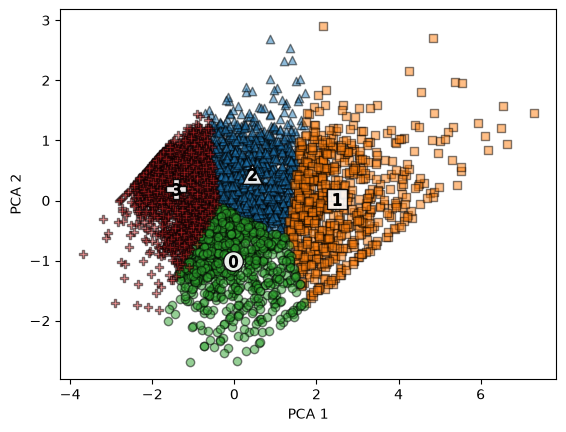

In [130]:
import matplotlib.pyplot as plt

markers = ['o', 's', '^', 'P']
unique_labels = customer_df['cluster'].unique()

for label in unique_labels:
    label_cluster = customer_df[customer_df['cluster'] == label]
    center = centers_pca[label]

    plt.scatter(x=label_cluster['pca_1'],
                y=label_cluster['pca_2'],
                edgecolors='k',
                alpha=0.5,
                marker=markers[label])

    plt.scatter(x=center[0], y=center[1], s=200, color='white',
                alpha=0.9, edgecolors='k', marker=markers[label])
    plt.scatter(x=center[0], y=center[1], s=70, color='k',
                edgecolors='k', marker='$%d$' % label)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [131]:
def visualize_silhouette(cluster_lists, X_features): 
    
    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math
    
    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)
    
    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성 
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)
    
    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):
        
        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산. 
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)
        
        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)
        
        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현. 
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

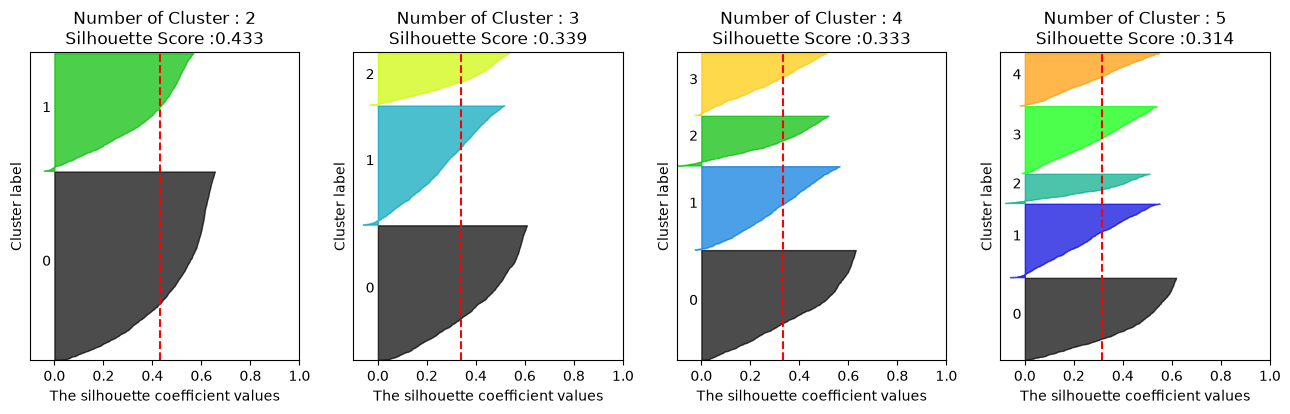

In [132]:
visualize_silhouette([2,3,4,5],X_scaled)